# Multi-Layer Perceptron (MLP)
Multi-Layer Perceptron (MLP) is a class of feedforward artificial neural network (ANN). It consists of at least three layers of nodes: an input layer, one or more hidden layers, and an output layer. Each node (or neuron) in one layer connects with a certain weight to every node in the following layer. 

## Structure of MLP
1. **Input Layer**: This layer receives the input features and passes them to the next layer. The number of neurons in this layer corresponds to the number of input features.
2. **Hidden Layers**: These layers perform computations and feature transformations. The number of hidden layers and the number of neurons in each layer can be adjusted based on the complexity of the problem.
3. **Output Layer**: This layer produces the final output of the network. The number of neurons in this layer corresponds to the number of output classes or regression targets.

In [5]:
# type: ignore
import warnings
warnings.filterwarnings('ignore')
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

Normalization Image Data

- We convert to gray scale and normalize the pixel values to be between 0 and 1. This is done by dividing the pixel values by 255 (the maximum pixel value for an 8-bit image).

In [6]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
grayscale = 255

# Normalize the pixel values to be between 0 and 1
x_train = x_train.astype('float32') / grayscale
x_test = x_test.astype('float32') / grayscale

print("Feature matrix (x_train) shape:", x_train.shape)
print("Target matrix (y_train) shape:", y_train.shape)
print("Feature matrix (x_test) shape:", x_test.shape)
print("Target matrix (y_test) shape:", y_test.shape)

Feature matrix (x_train) shape: (60000, 28, 28)
Target matrix (y_train) shape: (60000,)
Feature matrix (x_test) shape: (10000, 28, 28)
Target matrix (y_test) shape: (10000,)


Visualizing the data

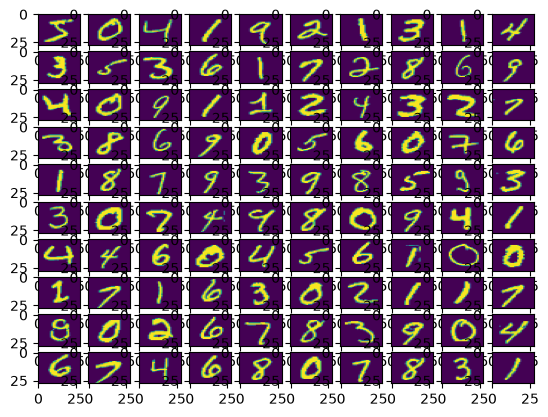

In [9]:
fig, ax = plt.subplots(10, 10)
k = 0
for i in range(10):
    for j in range(10):
        ax[i][j].imshow(x_train[k], aspect='auto')
        k += 1
plt.show()

## Build A Neural Network Model
A sequential model is a linear stack of layers. We can create a sequential model by passing a list of layer instances to the constructor.
- Flatten Layer: This layer flattens the input data into a 1D array. It does not affect the batch size. Coverts the 28 x 28 pixel images into a 784 element vector.
- Dense Layer: This layer is a fully connected layer. It takes the input from the previous layer and computes the output using the weights and biases. The number of neurons in this layer is specified by the units parameter. The activation function is specified by the activation parameter. In this case, we are using the ReLU activation function.
- Hidden Layer: This layer is a fully connected layer. It takes the input from the previous layer and computes the output using the weights and biases. The number of neurons in this layer is specified by the units parameter. The activation function is specified by the activation parameter. In this case, we are using the ReLU activation function.
- Output Layer: This layer is a fully connected layer. It takes the input from the previous layer and computes the output using the weights and biases. The number of neurons in this layer is specified by the units parameter. The activation function is specified by the activation parameter. In this case, we are using the softmax activation function.

In [11]:
model = Sequential([
    Flatten(input_shape=(28, 28)), # Flatten layer to convert 28x28 images into 784 element vectors
    Dense(256, activation='sigmoid'),  # Hidden layer with 256 neurons and ReLU activation
    Dense(128, activation='sigmoid'),   # Hidden layer with 128 neurons and ReLU activation
    Dense(10, activation='softmax') # Output layer with 10 neurons and softmax activation
])

Compile the model
- Optimizer: This parameter specifies the optimization algorithm to be used for training the model. In this case, we are using the Adam optimizer.
- Loss Function: This parameter specifies the loss function to be used for training the model. In this case, we are using the sparse categorical crossentropy loss function. This loss function is used for multi-class classification problems where the target variable is an integer representing the class label.
- Metrics: This parameter specifies the metrics to be evaluated by the model during training and testing. In this case, we are using the accuracy metric to evaluate the performance of the model.

In [13]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

6. Training the Model

We train the model using the training data. We specify the number of epochs (iterations over the entire dataset) and the batch size (number of samples per gradient update). The model will learn from the training data and adjust its weights to minimize the loss function.

In [16]:
mod = model.fit(x_train, y_train, epochs=15, batch_size=2000, validation_split=0.2)


Epoch 1/15


W0000 00:00:1789652552.464903   58236 cpu_allocator_impl.cc:82] Allocation of 150528000 exceeds 10% of free system memory.


24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.9259 - loss: 0.2639 - val_accuracy: 0.9300 - val_loss: 0.2475
Epoch 2/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.9293 - loss: 0.2505 - val_accuracy: 0.9322 - val_loss: 0.2371
Epoch 3/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.9322 - loss: 0.2386 - val_accuracy: 0.9362 - val_loss: 0.2263
Epoch 4/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.9349 - loss: 0.2274 - val_accuracy: 0.9377 - val_loss: 0.2183
Epoch 5/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.9376 - loss: 0.2181 - val_accuracy: 0.9399 - val_loss: 0.2105
Epoch 6/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.9401 - loss: 0.2085 - val_accuracy: 0.9429 - val_loss: 0.2025
Epoch 7/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.9424 - loss: 0.1997 - val_accuracy: 0.9447 - val_loss: 0.1964
Epoch 8/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.9447 - loss: 0.1917 - val_accuracy: 0.9462 - val_loss: 0.

In [17]:
results =  model.evaluate(x_test, y_test, verbose=1)
print('Test loss, Test accuracy:', results)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9544 - loss: 0.1542
Test loss, Test accuracy: [0.154172882437706, 0.9544000029563904]


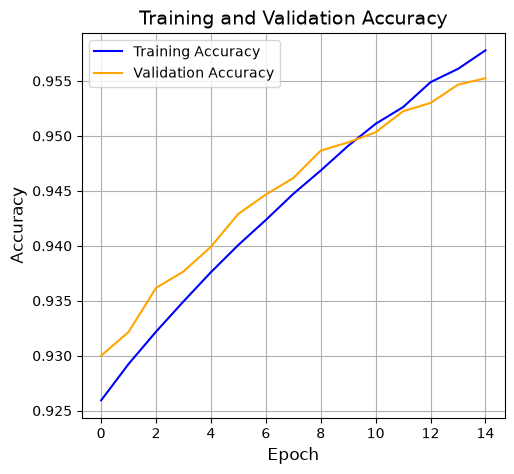

In [19]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(mod.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(mod.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()


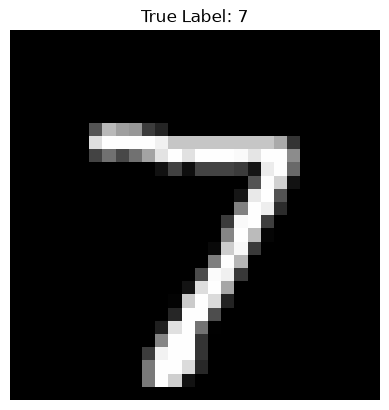

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
Predicted Label: 7


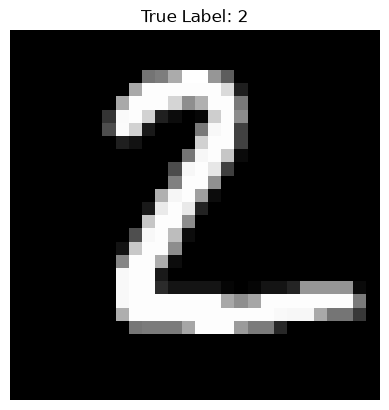

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
Predicted Label: 2


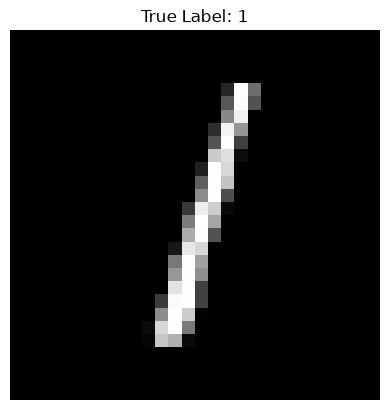

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
Predicted Label: 1


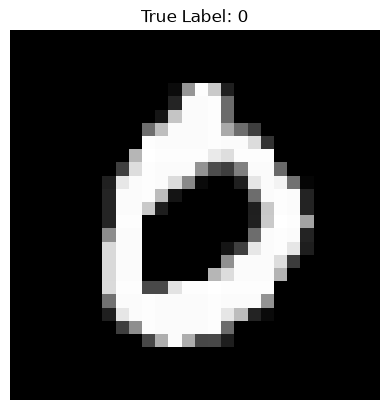

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
Predicted Label: 0


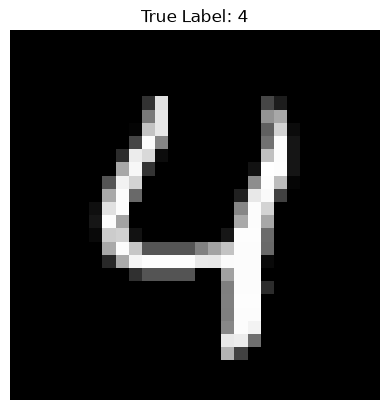

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
Predicted Label: 4


In [21]:
def plot_prediction(index):
    plt.imshow(x_test[index], cmap='gray')
    plt.title(f"True Label: {y_test[index]}")
    plt.axis('off')
    plt.show()

    prediction = model.predict(np.expand_dims(x_test[index], axis=0))
    predicted_label = np.argmax(prediction)
    print(f"Predicted Label: {predicted_label}")

for i in range(5):
    plot_prediction(i)

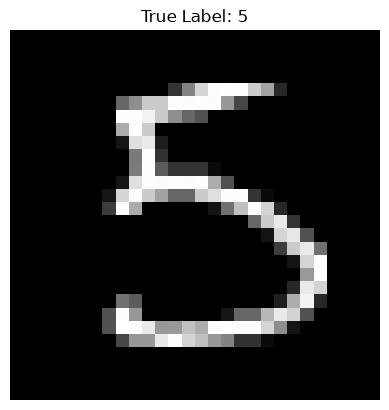

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
Predicted Label: 5


In [22]:
plot_prediction(15)